Single KNN Prediction: 0
Bagging KNN Prediction: 1
Estimator 1 prediction: 1
Estimator 2 prediction: 0
Estimator 3 prediction: 0
Estimator 4 prediction: 1
Estimator 5 prediction: 0
Estimator 6 prediction: 1
Estimator 7 prediction: 1


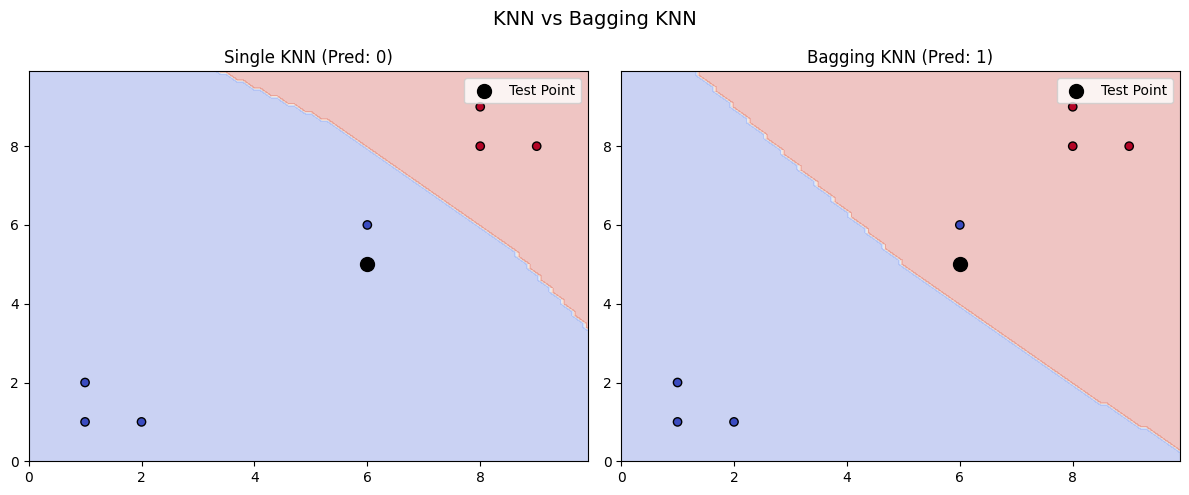

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
# Simple dataset
X = np.array([
  [1, 1], [1, 2], [2, 1],  # class 0
  [8, 8], [8, 9], [9, 8],  # class 1
  [6, 6]                   # class 0
])
y = np.array([0, 0, 0, 1, 1, 1, 0])
# Test point
X_test = np.array([[6, 5]])
# 🎯 Single KNN
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)
pred_single = knn.predict(X_test)[0]
# 🪄 Bagging KNN
bag_knn = BaggingClassifier(
   estimator=KNeighborsClassifier(n_neighbors=1),
   n_estimators=7,
   max_samples=0.8,
   bootstrap=True,
   random_state=42
)
bag_knn.fit(X, y)
pred_bag = bag_knn.predict(X_test)[0]
# Show predictions
print("Single KNN Prediction:", pred_single)
print("Bagging KNN Prediction:", pred_bag)
for i, est in enumerate(bag_knn.estimators_):
   print(f"Estimator {i+1} prediction: {est.predict(X_test)[0]}")
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                    np.arange(y_min, y_max, h))
mesh_points = np.c_[xx.ravel(), yy.ravel()]
# Predictions for plot
Z_single = knn.predict(mesh_points).reshape(xx.shape)
Z_bag = bag_knn.predict(mesh_points).reshape(xx.shape)
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Plot Single KNN
axs[0].contourf(xx, yy, Z_single, cmap=plt.cm.coolwarm, alpha=0.3)
axs[0].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
axs[0].scatter(X_test[0, 0], X_test[0, 1], color='black', s=100, label='Test Point')
axs[0].set_title(f"Single KNN (Pred: {pred_single})")
axs[0].legend()
# Plot Bagging KNN
axs[1].contourf(xx, yy, Z_bag, cmap=plt.cm.coolwarm, alpha=0.3)
axs[1].scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
axs[1].scatter(X_test[0, 0], X_test[0, 1], color='black', s=100, label='Test Point')
axs[1].set_title(f"Bagging KNN (Pred: {pred_bag})")
axs[1].legend()
plt.suptitle("KNN vs Bagging KNN", fontsize=14)
plt.tight_layout()
plt.show()